# Import Libraries & Functions I'll need.

In [1]:
## INSTRUCTIONS TO SELF:
# -> CONDA ACTIVATE ml2_asg
# -> mlflow server --host 127.0.0.1 --port 5000

In [2]:
# Standard library
import os
import json

# Third-party: data & utils
import joblib
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scikit-learn
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

# Experiment tracking (MLflow)
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# Drift monitoring (Evidently)
from evidently.metric_preset import DataDriftPreset
from evidently.report import Report


In [3]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return rmse, mae, r2

In [4]:
def evaluate_cv(model, X_train, y_train, cv_folds=5):
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        cv=cv,
        return_train_score=False
    )

    rmse_mean = -scores["test_rmse"].mean()
    rmse_std  = scores["test_rmse"].std()

    mae_mean = -scores["test_mae"].mean()
    r2_mean  = scores["test_r2"].mean()

    return {
        "cv_rmse_mean": rmse_mean,
        "cv_rmse_std": rmse_std,
        "cv_mae_mean": mae_mean,
        "cv_r2_mean": r2_mean
    }

# 1.0 Data Preprocessing on 2011 datasets

## 1.1 Load Data

In [5]:
# Load 2011 dataset -> Task 1
df_2011 = pd.read_csv("day_2011.csv")
df_2011.head()

,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,01/01/2011,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,02/01/2011,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,03/01/2011,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,04/01/2011,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,05/01/2011,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [6]:
# find categorical variables 
# Datatype -> 'Object' (contains text/ string values) -> Categorical
cat_cols_2011 = [c for c in df_2011.columns if df_2011[c].dtypes=='O']
df_2011[cat_cols_2011].isnull().sum()

dteday    0
dtype: int64

In [7]:
# find numerical variables
num_cols_2011 = [c for c in df_2011.columns if df_2011[c].dtypes!='O']
df_2011[num_cols_2011].isnull().sum()

season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

## 1.2 Perform Exploratory Data Analysis (EDA)
Here are my findings: 
- All features except 'dteday' are numerical. 
- No null values observed -> No need to handle any missing values.

In [8]:
df_2011.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      365 non-null    object 
 1   season      365 non-null    int64  
 2   mnth        365 non-null    int64  
 3   holiday     365 non-null    int64  
 4   weekday     365 non-null    int64  
 5   workingday  365 non-null    int64  
 6   weathersit  365 non-null    int64  
 7   temp        365 non-null    float64
 8   atemp       365 non-null    float64
 9   hum         365 non-null    float64
 10  windspeed   365 non-null    float64
 11  cnt         365 non-null    int64  
dtypes: float64(4), int64(7), object(1)
memory usage: 34.3+ KB


In [9]:
df_2011.describe()

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2.498630,6.526027,0.027397,3.008219,0.684932,1.421918,0.486665,0.466835,0.643665,0.191403,3405.761644
std,1.110946,3.452584,0.163462,2.006155,0.465181,0.571831,0.189596,0.168836,0.148744,0.076890,1378.753666
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,431.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.325000,0.321954,0.538333,0.135583,2132.000000
50%,3.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.479167,0.472846,0.647500,0.186900,3740.000000
75%,3.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.656667,0.612379,0.742083,0.235075,4586.000000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.849167,0.840896,0.972500,0.507463,6043.000000


In [10]:
# to visualise the number of missing values for each variables
df_2011.isnull().sum()

dteday        0
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [11]:
df_2011.head()

,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,01/01/2011,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,02/01/2011,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,03/01/2011,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,04/01/2011,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,05/01/2011,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


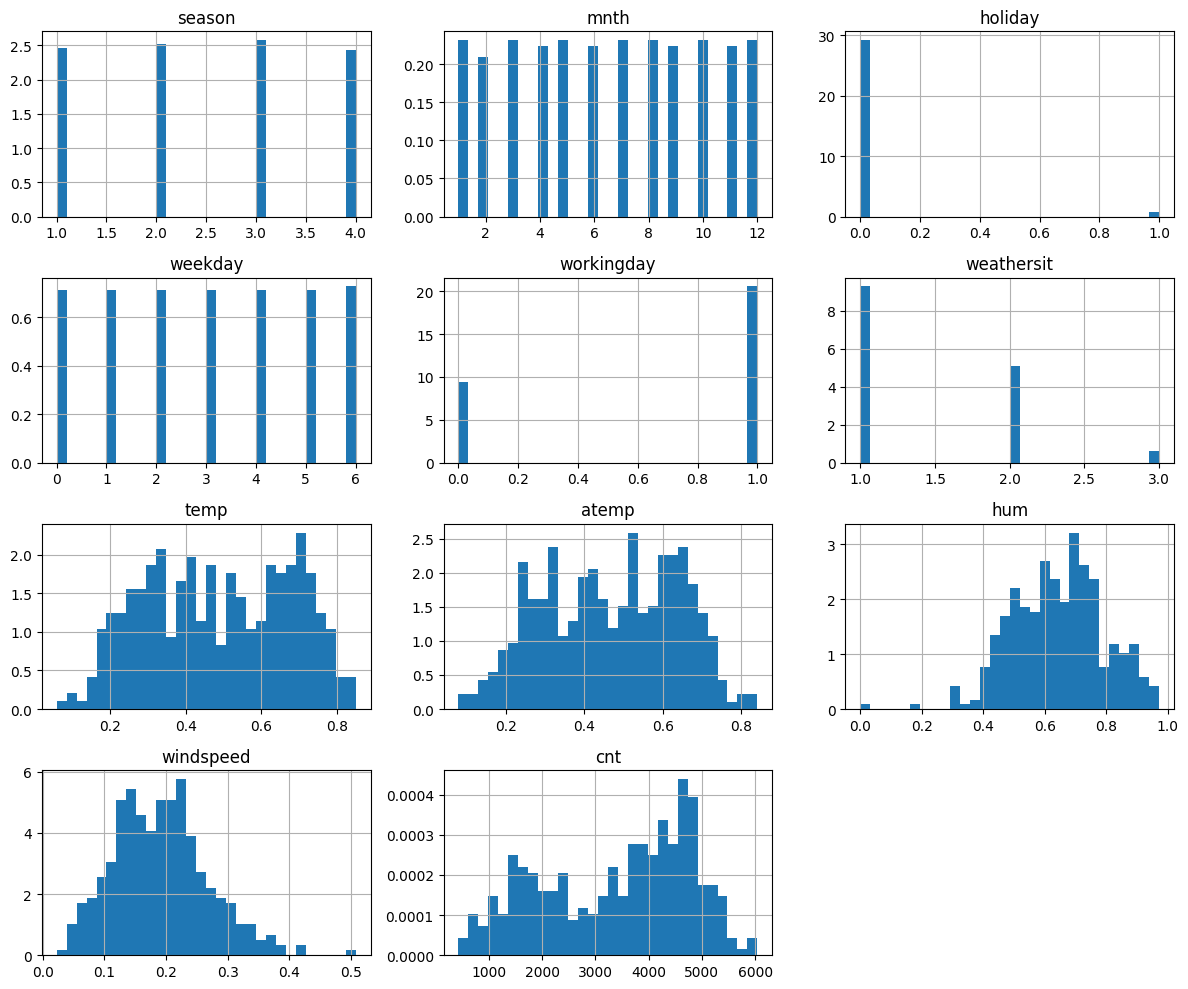

In [12]:
# plotting the histogram to the num variables
df_2011[num_cols_2011].hist(bins=30, figsize=(12, 10), density=True) # note: from DW practical 1.7
plt.tight_layout()
plt.show()

In [13]:
# print unique values per column
for col in df_2011.columns:
    print(f"{col}: {df_2011[col].nunique()} unique values")

dteday: 365 unique values
season: 4 unique values
mnth: 12 unique values
holiday: 2 unique values
weekday: 7 unique values
workingday: 2 unique values
weathersit: 3 unique values
temp: 294 unique values
atemp: 353 unique values
hum: 332 unique values
windspeed: 349 unique values
cnt: 352 unique values


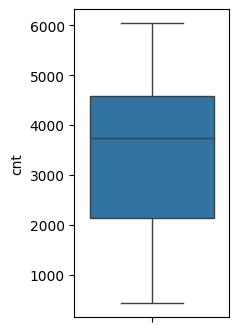

In [14]:
# Explore the distributuion of price variable
plt.figure(figsize=(2, 4))
sns.boxplot(y=df_2011['cnt'])
plt.show()

In [15]:
df_2011['cnt'].describe()

count     365.000000
mean     3405.761644
std      1378.753666
min       431.000000
25%      2132.000000
50%      3740.000000
75%      4586.000000
max      6043.000000
Name: cnt, dtype: float64

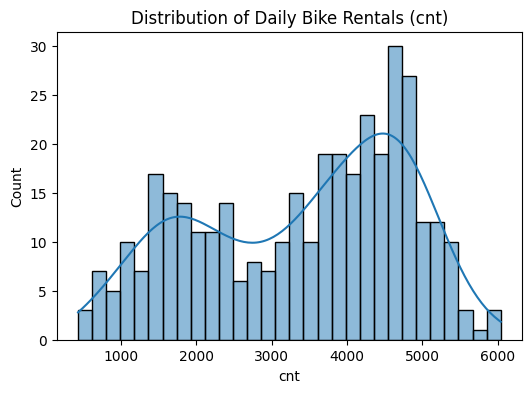

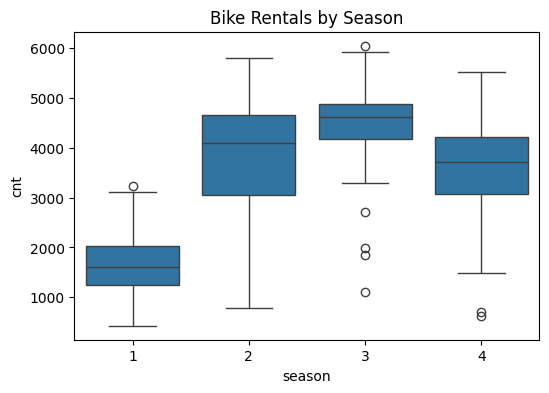

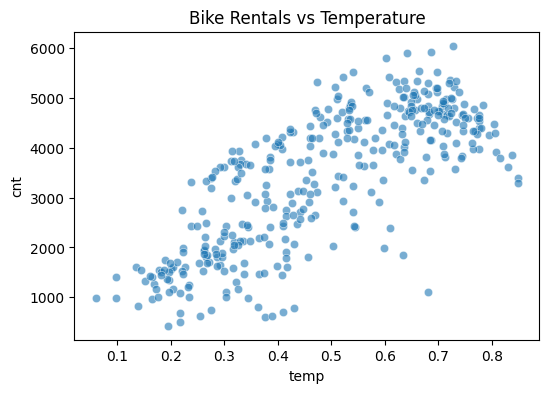

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df_2011["cnt"], bins=30, kde=True)
plt.title("Distribution of Daily Bike Rentals (cnt)")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="season", y="cnt", data=df_2011)
plt.title("Bike Rentals by Season")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="temp", y="cnt", data=df_2011, alpha=0.6)
plt.title("Bike Rentals vs Temperature")
plt.show()

## 1.3 Cleanse and Transform the data on 2011 dataset
- No need to handle missing values.
- Overall findings for 'dteday' -> No feature extraction needed.
  - month not extracted. redundant to extract because feature 'mnth' already exists.
  - weekday not extracted. redundant to extract because feature 'weekday' already exists.
  - day of the year not extracted. Does not provide useful information for the model. Each dayofyear value is unique.
  - Therefore, feature 'dteday' is dropped because dataset already provided explicit calendar features (e.g. 'season', 'mnth', 'weekday'), making additional extraction unnecessary. 
- According to the correlation analysis, features 'temp' and 'atemp' are prefectly correlated. After testing with the baseline model, feature 'atemp' was removed as baseline model performed better when 'atemp' was removed compared to 'temp'.
- Finally, a pipeline was done, that performs One-Hot Encoding on categorical features, even though they were already encoded ordinally.
- Numerical features left unchanged -> Not transformed/ normalized -> because according to assignment outline, they are alreayd normalized.
- Target feature 'cnt' not transformed, because it is not skewed, distribution is approximately symmetric. It was also done so to prevent model from making predictions that will result in non-integer values. Since 'cnt' of rentals must be integer. 

### Handling missing values & Changing datatype

In [17]:
# Another check to confirm no missing values in df_2011
df_2011.isnull().sum()

dteday        0
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [18]:
# Feature extraction -> Not needed, drop 'dteday'

# df_2011["dteday"] = pd.to_datetime(df_2011["dteday"], dayfirst=True)
# df_2011["month_from_date"] = df_2011["dteday"].dt.month 
# df_2011["weekday_from_date"] = df_2011["dteday"].dt.weekday
# df_2011["dayofyear"] = df_2011["dteday"].dt.dayofyear

# Drop the original datetime column
df_2011 = df_2011.drop(columns=["dteday"])
df_2011.head() # check for changes

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [19]:
# another check for 'dteday' dropped
df_2011.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      365 non-null    int64  
 1   mnth        365 non-null    int64  
 2   holiday     365 non-null    int64  
 3   weekday     365 non-null    int64  
 4   workingday  365 non-null    int64  
 5   weathersit  365 non-null    int64  
 6   temp        365 non-null    float64
 7   atemp       365 non-null    float64
 8   hum         365 non-null    float64
 9   windspeed   365 non-null    float64
 10  cnt         365 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 31.5 KB


### Correlation Analysis

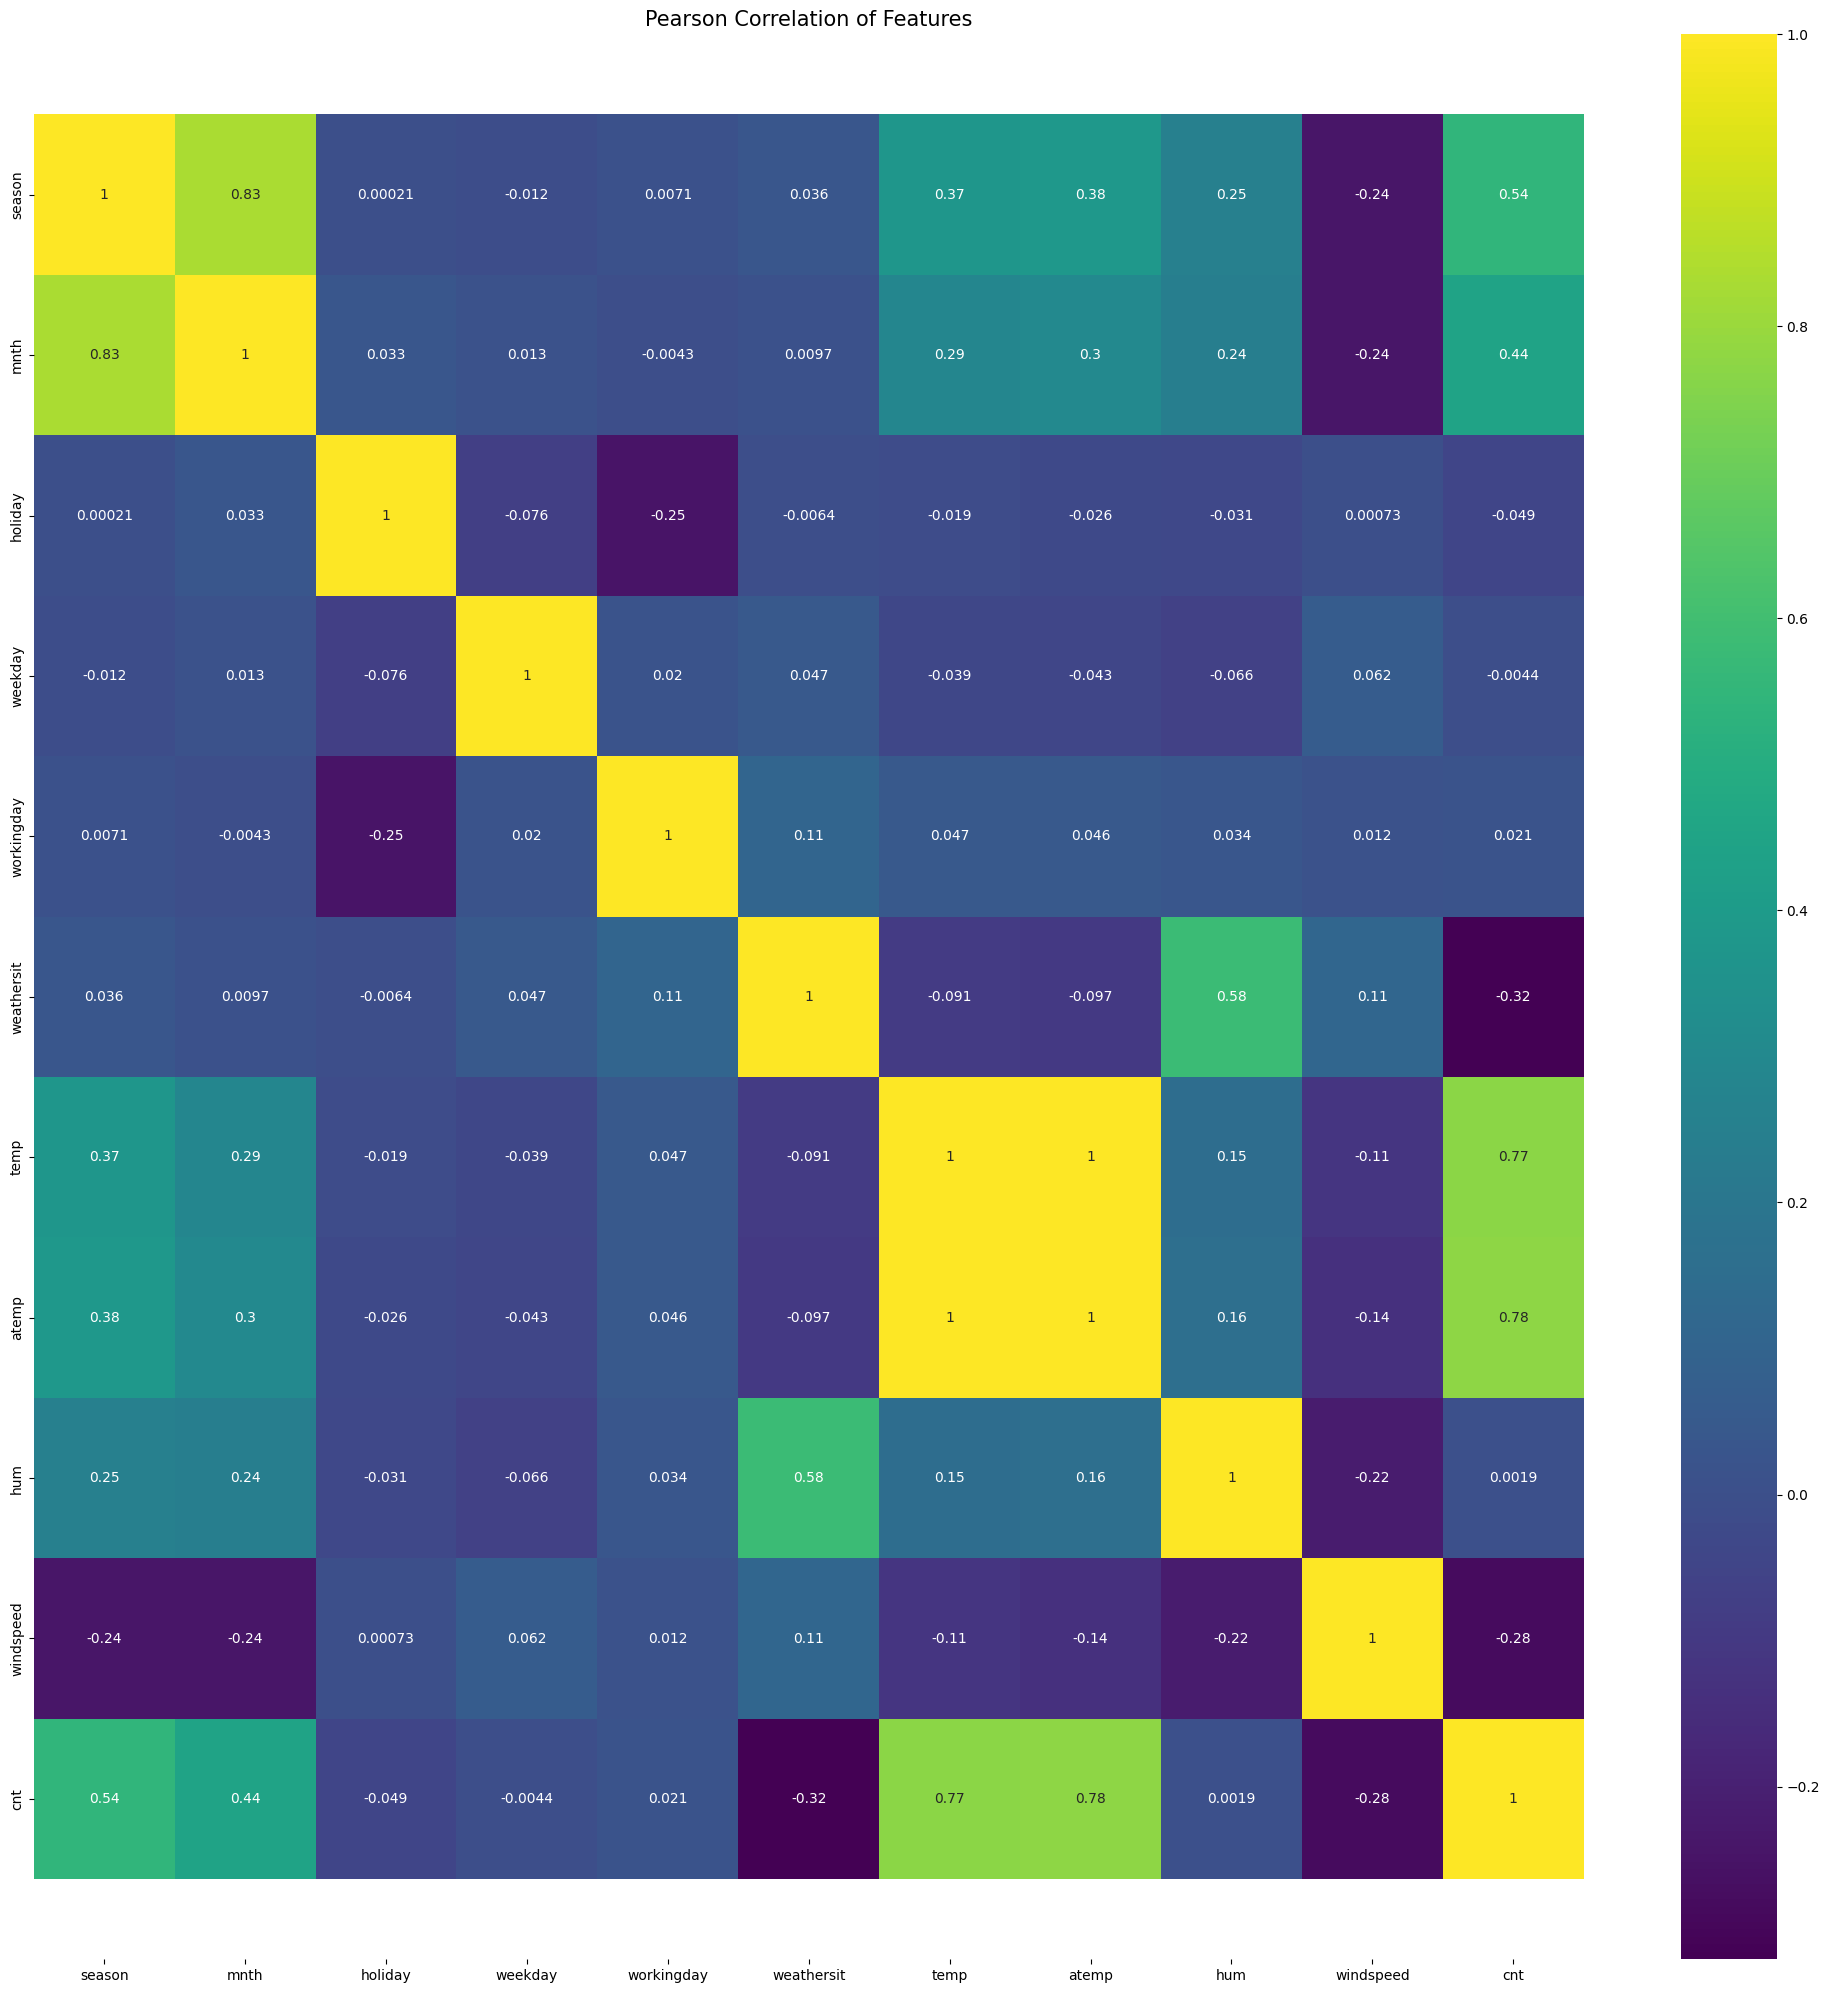

In [20]:
colormap = plt.cm.viridis
plt.figure(figsize=(25,25))
plt.title('Pearson Correlation of Features', size=15)
ax = sns.heatmap(df_2011.corr(), cmap=colormap, annot=True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

#### Proper testing conducted to drop high collinearity feature
The heatmap shows 'temp' and 'atemp' have a perfect positive correlation of 1. This indicates that the two features are basically representing the same information, which means that the model will learn twice.

I tested three scenarios. Dropping 'atemp' resulted in the best performance while keeping the model simpler. Since 'temp' and 'atemp' were perfectly correlated, removing 'atemp' reduced redundancy without sacrificing accuracy.

In [21]:
df_2011 = df_2011.drop(columns=['atemp'])

### Applying Preprocessing Piepline 
While the features are numerically encoded, several represent categorical variables. One-Hot Encoding was applied to prevent the model from assuming ordinal relationships between categories and to allow independent effects to be learned for each category. In addition, there's evidence to backup my claim as the RSME after preprocessing decreases. 

Before preprocessing:
- Model underfits. Train RMSE > Test RMSE. Indicates model is too simple.   
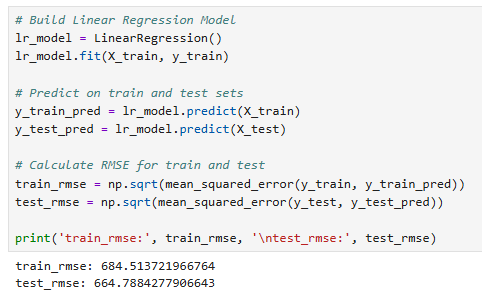 

After Preprocessing:   
- Model's performance improves. Train & Test error (RMSE) dropped significantly. Model no longer underfits.   
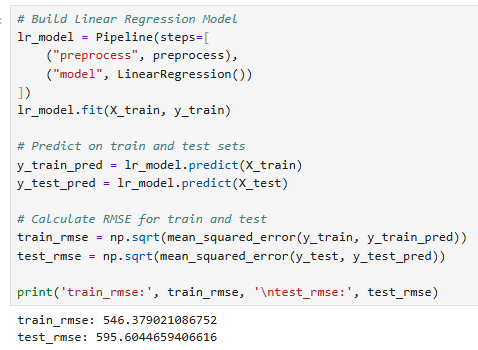

In [22]:
categorical_features = [
    "season", "mnth", "holiday",
    "weekday", "weathersit", "workingday"
]

numeric_features = ["temp", "hum", "windspeed"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features), # applies OHE to cat-features 
        ("num", "passthrough", numeric_features) # Does nth with numerical feature
    ]
)

## 1.4 Train-test split

In [23]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df_2011.drop(columns='cnt'), # keep feature columns -> exclude target variable
    df_2011['cnt'], # The Target Variable
    test_size=0.2, # training (80%) and testing sets (20%)
    random_state=67 # random seed
    )

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (292, 9)
Test size: (73, 9)


# 2.0 Task 1: MLflow Experiment Tracking

## 2.1 MLflow Setup

In [24]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri("http://localhost:5000")

# Create a new MLflow Experiment
mlflow.set_experiment("ML2_Task1_Bike_Sharing_2011")

<Experiment: artifact_location='mlflow-artifacts:/6', creation_time=1770304570822, experiment_id='6', last_update_time=1770304570822, lifecycle_stage='active', name='ML2_Task1_Bike_Sharing_2011', tags={'mlflow.experimentKind': 'custom_model_development'}>

## 2.2 Experiment 1 -> Baseline Linear Regression Model

### 2.2.1 Create & Train Naive Baseline model using Linear Regression

In [25]:
# Build Linear Regression Model
lr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
lr_model.fit(X_train, y_train)

# Predict on train and test sets
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Calculate RMSE for train and test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('train_rmse:', train_rmse, '\ntest_rmse:', test_rmse)

train_rmse: 539.0865171678894 
test_rmse: 611.8478788923644


In [26]:
# Cross-validation on train set ONLY!!
cv_results = evaluate_cv(lr_model, X_train, y_train)

print("CV RMSE:", cv_results["cv_rmse_mean"], "+/-", cv_results["cv_rmse_std"])

# Final evaluation on TEST set
test_rmse, test_mae, test_r2 = evaluate(lr_model, X_test, y_test)

print("Test RMSE:", test_rmse)

CV RMSE: 582.613754785586 +/- 100.35556407822007
Test RMSE: 611.8478788923644


### 2.2.2 Log the model and its metadata to MLflow

In [27]:
params_baseline = {
    "model_type": "LinearRegression",
    "preprocessing": "OneHotEncode categorical + passthrough numeric",
    "categorical_features": ",".join(categorical_features),
    "numeric_features": ",".join(numeric_features),
}

BASELINE_RUN_ID = None

# Start an MLflow run
with mlflow.start_run(run_name="Baseline_Linear_Regression") as run:
    BASELINE_RUN_ID = run.info.run_id
    
    # Tags are searchable labels in MLflow UI
    mlflow.set_tag("role", "baseline")
    mlflow.set_tag("dataset", "df_2011")
    mlflow.set_tag("problem_type", "regression")
    
    # Log the hyperparameters
    mlflow.log_params(params_baseline)

    # Log regression metrics
    # Evaluate using evaluate() function that returns rmse, mae, r2
    rmse_lr, mae_lr, r2_lr = evaluate(lr_model, X_test, y_test) # evaluates on the test set
    mlflow.log_metric("rmse", rmse_lr)
    mlflow.log_metric("mae", mae_lr)
    mlflow.log_metric("r2", r2_lr)

    # Infer the model signature
    signature = infer_signature(X_train, lr_model.predict(X_train))

    # Log the model, which inherits the parameters and metric
    model_info = mlflow.sklearn.log_model(
        sk_model=lr_model,
        name="LinearRegressionModel",
        signature=signature,
        input_example=X_train.iloc[:5],
        registered_model_name="LinearRegressionModel",
    )

    # Set a tag that we can use to remind ourselves what this model was for
    mlflow.set_logged_model_tags(
        model_info.model_id, {"Training Info": "Basic LR model for 2011 data"}
    )

print("Baseline Run ID:", BASELINE_RUN_ID)

C:\Users\maxlo\anaconda3\envs\ml2_asg\lib\site-packages\mlflow\types\utils.py:452: UserWarning:

Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.

C:\Users\maxlo\anaconda3\envs\ml2_asg\lib\site-packages\mlflow\models\model.py:1209: FutureWarning:

Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializa

Registered model 'LinearRegressionModel' already exists. Creating a new version of this model...
2026/02/08 21:11:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LinearRegressionModel, version 12
Created version '12' of model 'LinearRegressionModel'.


🏃 View run Baseline_Linear_Regression at: http://localhost:5000/#/experiments/6/runs/fc93e389f29742939569276277125868
🧪 View experiment at: http://localhost:5000/#/experiments/6
Baseline Run ID: fc93e389f29742939569276277125868


## 2.3 Experiment 2 -> Improved model (Ridge Regression)

### 2.3.1 Create and Train improved model using Ridge Regression
Upon testing different alpha values, alpha = 0.5 gave the best performance, with the lowest test RMSE score. 
- When alpha = 0.5:   
  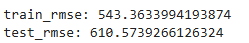
- When alpha = 1.0   
  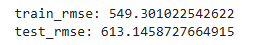
- When alpha = 2.0   
  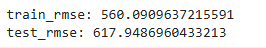   

In [28]:
alpha = 0.5

ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=alpha, random_state=42))
])

ridge_model.fit(X_train, y_train)

# Predict on train and test sets
y_train_pred = ridge_model.predict(X_train)
y_test_pred = ridge_model.predict(X_test)

# Calculate RMSE for train and test
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('train_rmse:', train_rmse, '\ntest_rmse:', test_rmse)

train_rmse: 543.3633994193874 
test_rmse: 610.5739266126324


In [29]:
# Cross-validation on train set ONLY!!
cv_results = evaluate_cv(ridge_model, X_train, y_train)

print("CV RMSE:", cv_results["cv_rmse_mean"], "+/-", cv_results["cv_rmse_std"])

# Final evaluation on TEST set
test_rmse, test_mae, test_r2 = evaluate(ridge_model, X_test, y_test)

print("Test RMSE:", test_rmse)

CV RMSE: 586.1458577343545 +/- 99.49753285766228
Test RMSE: 610.5739266126324


### 2.3.2 Log the model and its metadata to MLflow

In [30]:
params_ridge = {
    "model_type": "RidgeRegression",
    "alpha": alpha,
    "improvement_strategy": "L2 regularisation",
    "preprocessing": "OneHotEncode categorical + passthrough numeric",
    "categorical_features": ",".join(categorical_features),
    "numeric_features": ",".join(numeric_features),
}

IMPROVED_RUN_ID = None

# Start an MLflow run
with mlflow.start_run(run_name="Ridge_Regression") as run:
    IMPROVED_RUN_ID = run.info.run_id
    
    # Tags are searchable labels in MLflow UI
    mlflow.set_tag("role", "Improved")
    mlflow.set_tag("dataset", "df_2011")
    mlflow.set_tag("problem_type", "regression")
    
    # Log parameters
    mlflow.log_params(params_ridge)

    # Log regression metrics
    # Evaluate using evaluate() function that returns rmse, mae, r2
    rmse_rr, mae_rr, r2_rr = evaluate(ridge_model, X_test, y_test)
    mlflow.log_metric("rmse", rmse_rr)
    mlflow.log_metric("mae", mae_rr)
    mlflow.log_metric("r2", r2_rr)

    # Infer the model signature
    signature = infer_signature(X_train, lr_model.predict(X_train))

    # Log the model, which inherits the parameters and metric
    model_info = mlflow.sklearn.log_model(
        sk_model=ridge_model,
        name="RidgeRegressionModel",
        signature=signature,
        input_example=X_train.iloc[:5],
        registered_model_name="RidgeRegressionModel",
    )
    
    # Set a tag that we can use to remind ourselves what this model was for
    mlflow.set_logged_model_tags(
        model_info.model_id, {"Training Info": "Ridge Regression model for 2011 data"}
    )

print("Improved Run ID:", IMPROVED_RUN_ID)

C:\Users\maxlo\anaconda3\envs\ml2_asg\lib\site-packages\mlflow\types\utils.py:452: UserWarning:

Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.

C:\Users\maxlo\anaconda3\envs\ml2_asg\lib\site-packages\mlflow\models\model.py:1209: FutureWarning:

Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serializa

Registered model 'RidgeRegressionModel' already exists. Creating a new version of this model...
2026/02/08 21:12:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RidgeRegressionModel, version 9
Created version '9' of model 'RidgeRegressionModel'.


🏃 View run Ridge_Regression at: http://localhost:5000/#/experiments/6/runs/7e409a2b9d1d43bf84105da038affc48
🧪 View experiment at: http://localhost:5000/#/experiments/6
Improved Run ID: 7e409a2b9d1d43bf84105da038affc48


# 3.0 Task 2: Data Drift Analysis and Impact Assessment

## 3.1 Load the 2012 dataset ('day_2012')

In [31]:
# Load 2012 dataset
df_2012 = pd.read_csv("day_2012.csv")
df_2012.head()

,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,01/01/2012,1,1,0,0,0,1,0.370000,0.375621,0.692500,0.192167,2294
1,02/01/2012,1,1,1,1,0,1,0.273043,0.252304,0.381304,0.329665,1951
2,03/01/2012,1,1,0,2,1,1,0.150000,0.126275,0.441250,0.365671,2236
3,04/01/2012,1,1,0,3,1,2,0.107500,0.119337,0.414583,0.184700,2368
4,05/01/2012,1,1,0,4,1,1,0.265833,0.278412,0.524167,0.129987,3272


In [32]:
# find categorical variables 
# Datatype -> 'Object' (contains text/ string values) -> Categorical
cat_cols_2012 = [c for c in df_2012.columns if df_2012[c].dtypes=='O']
df_2012[cat_cols_2012].isnull().sum()

dteday    0
dtype: int64

In [33]:
# find numerical variables
num_cols_2012 = [c for c in df_2012.columns if df_2012[c].dtypes!='O']
df_2012[num_cols_2012].isnull().sum()

season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

## 3.2 Perform Exploratory Data Analysis (EDA) on 2012 datasets
Here are my findings:
- All features except 'dteday' are numerical.
- No null values observed -> No need to handle any missing values.

In [34]:
df_2012.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      366 non-null    object 
 1   season      366 non-null    int64  
 2   mnth        366 non-null    int64  
 3   holiday     366 non-null    int64  
 4   weekday     366 non-null    int64  
 5   workingday  366 non-null    int64  
 6   weathersit  366 non-null    int64  
 7   temp        366 non-null    float64
 8   atemp       366 non-null    float64
 9   hum         366 non-null    float64
 10  windspeed   366 non-null    float64
 11  cnt         366 non-null    int64  
dtypes: float64(4), int64(7), object(1)
memory usage: 34.4+ KB


In [35]:
df_2011.describe()

,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2.498630,6.526027,0.027397,3.008219,0.684932,1.421918,0.486665,0.643665,0.191403,3405.761644
std,1.110946,3.452584,0.163462,2.006155,0.465181,0.571831,0.189596,0.148744,0.076890,1378.753666
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.000000,0.022392,431.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.325000,0.538333,0.135583,2132.000000
50%,3.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.479167,0.647500,0.186900,3740.000000
75%,3.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.656667,0.742083,0.235075,4586.000000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.849167,0.972500,0.507463,6043.000000


In [36]:
df_2012.describe()

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.494536,6.513661,0.030055,2.986339,0.683060,1.368852,0.504081,0.481852,0.612166,0.189572,5599.934426
std,1.112185,3.455958,0.170971,2.006108,0.465921,0.516057,0.176112,0.156756,0.134206,0.078194,1788.667868
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.107500,0.101658,0.254167,0.046650,22.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.347708,0.350685,0.508125,0.133721,4369.000000
50%,2.500000,7.000000,0.000000,3.000000,1.000000,1.000000,0.514167,0.497779,0.611875,0.174750,5927.000000
75%,3.000000,9.750000,0.000000,5.000000,1.000000,2.000000,0.653959,0.607646,0.711146,0.231196,7011.250000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.804913,0.925000,0.441563,8714.000000


In [37]:
# to visualise the number of missing values for each variables
df_2012.isnull().sum()

dteday        0
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [38]:
df_2012.head()

,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,01/01/2012,1,1,0,0,0,1,0.370000,0.375621,0.692500,0.192167,2294
1,02/01/2012,1,1,1,1,0,1,0.273043,0.252304,0.381304,0.329665,1951
2,03/01/2012,1,1,0,2,1,1,0.150000,0.126275,0.441250,0.365671,2236
3,04/01/2012,1,1,0,3,1,2,0.107500,0.119337,0.414583,0.184700,2368
4,05/01/2012,1,1,0,4,1,1,0.265833,0.278412,0.524167,0.129987,3272


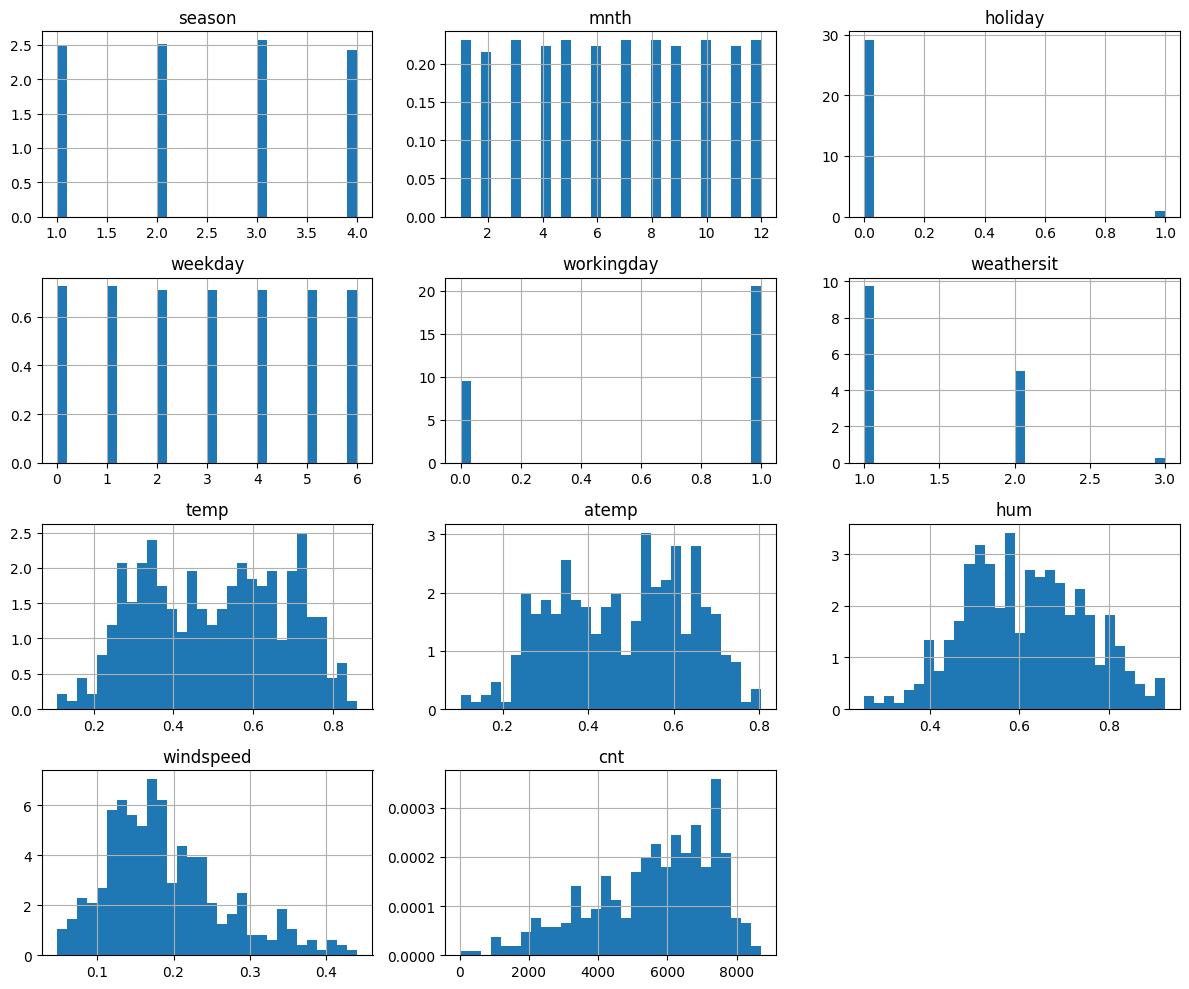

In [39]:
# plotting the histogram to the num variables
df_2012[num_cols_2012].hist(bins=30, figsize=(12, 10), density=True) # note: from DW practical 1.7
plt.tight_layout()
plt.show()

In [40]:
# print unique values per column
for col in df_2012.columns:
    print(f"{col}: {df_2012[col].nunique()} unique values")

dteday: 366 unique values
season: 4 unique values
mnth: 12 unique values
holiday: 2 unique values
weekday: 7 unique values
workingday: 2 unique values
weathersit: 3 unique values
temp: 293 unique values
atemp: 357 unique values
hum: 319 unique values
windspeed: 342 unique values
cnt: 356 unique values


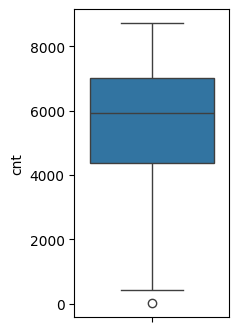

In [41]:
# Explore the distributuion of price variable
plt.figure(figsize=(2, 4))
sns.boxplot(y=df_2012['cnt'])
plt.show()

In [42]:
df_2012['cnt'].describe()

count     366.000000
mean     5599.934426
std      1788.667868
min        22.000000
25%      4369.000000
50%      5927.000000
75%      7011.250000
max      8714.000000
Name: cnt, dtype: float64

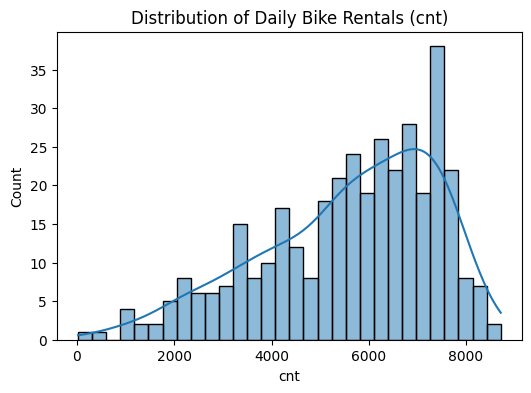

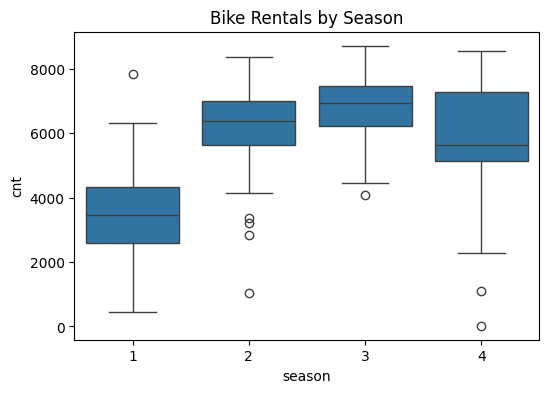

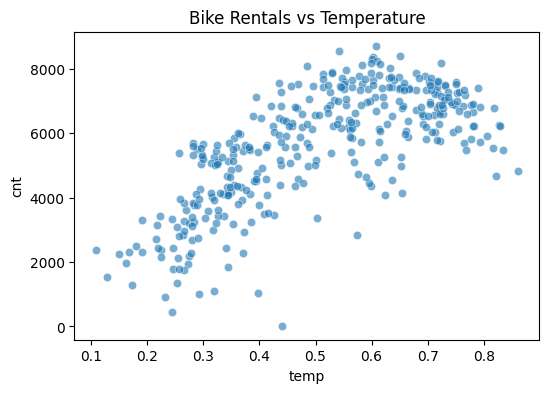

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(df_2012["cnt"], bins=30, kde=True)
plt.title("Distribution of Daily Bike Rentals (cnt)")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="season", y="cnt", data=df_2012)
plt.title("Bike Rentals by Season")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="temp", y="cnt", data=df_2012, alpha=0.6)
plt.title("Bike Rentals vs Temperature")
plt.show()

## 3.3 Perform same data cleaning on 2012 dataset

In [44]:
# drops features 'dteday' and 'atemp'
df_2012 = df_2012.drop(columns=['dteday', 'atemp'])

In [45]:
# Verify changes
df_2012.head()

,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,1,0,0,0,1,0.370000,0.692500,0.192167,2294
1,1,1,1,1,0,1,0.273043,0.381304,0.329665,1951
2,1,1,0,2,1,1,0.150000,0.441250,0.365671,2236
3,1,1,0,3,1,2,0.107500,0.414583,0.184700,2368
4,1,1,0,4,1,1,0.265833,0.524167,0.129987,3272


### 3.3.1 Train-test-split on 2012 dataset

In [46]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df_2012.drop(columns='cnt'), # keep feature columns -> exclude target variable
    df_2012['cnt'], # The Target Variable
    test_size=0.2, # training (80%) and testing sets (20%)
    random_state=67 # random seed
    )

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (292, 9)
Test size: (74, 9)


## 3.4 Drift Analysis

### 3.4.1 Compare using Simple Descriptive Statistics
Compare feature distributions between the datasets day_2011.csv and day_2012.csv
- Drift Ratio: change in mean relative to the feature’s spread (standard deviation).
  - Mean
  - Standard Deviation

My findings: 
- 'hum' has the strongest drift, with a drift ratio of 0.212.
- 'weathersit' and 'temp' are the second and third highest drift factors with drift raito of 0.0928 and 0.0919 respectively. 
- Features that have minor drift are 'weekday', 'mnth', 'season', 'holiday', 'workingday', 'windspeed'.

In [47]:
# Reference dataset (historical)
reference = df_2011.copy()
X_ref = reference.drop(columns="cnt")
y_ref = reference["cnt"]

# Current dataset 
current = df_2012.copy()
X_curr = current.drop(columns="cnt")
y_curr = current["cnt"]

# Quick sanity check: compare means
summary = pd.DataFrame({
    "mean_2011": X_ref.mean(),
    "mean_2012": X_curr.mean(),
    "std_2011": X_ref.std(),
    "std_2012": X_curr.std()
})

# Calculate drift
summary["mean_change"] = summary["mean_2012"] - summary["mean_2011"]
summary["std_change"] = summary["std_2012"] - summary["std_2011"]

# absolute change (easier to interpret cuz it's in +ve values)
summary["mean_change"] = summary["mean_change"].abs()
summary["std_change"] = summary["std_change"].abs()

# Calculate drift ratio
summary["drift_ratio"] = summary["mean_change"] / summary["std_2011"]

# sort by most drifted features
summary = summary.sort_values(by="drift_ratio", ascending=False)

summary

,mean_2011,mean_2012,std_2011,std_2012,mean_change,std_change,drift_ratio
hum,0.643665,0.612166,0.148744,0.134206,0.031498,0.014538,0.211762
weathersit,1.421918,1.368852,0.571831,0.516057,0.053065,0.055774,0.092799
temp,0.486665,0.504081,0.189596,0.176112,0.017416,0.013483,0.091858
windspeed,0.191403,0.189572,0.076890,0.078194,0.001830,0.001304,0.023805
holiday,0.027397,0.030055,0.163462,0.170971,0.002657,0.007509,0.016257
weekday,3.008219,2.986339,2.006155,2.006108,0.021880,0.000047,0.010907
workingday,0.684932,0.683060,0.465181,0.465921,0.001871,0.000740,0.004023
season,2.498630,2.494536,1.110946,1.112185,0.004095,0.001239,0.003686
mnth,6.526027,6.513661,3.452584,3.455958,0.012366,0.003374,0.003582


### 3.4.2 Visualising Data Drift

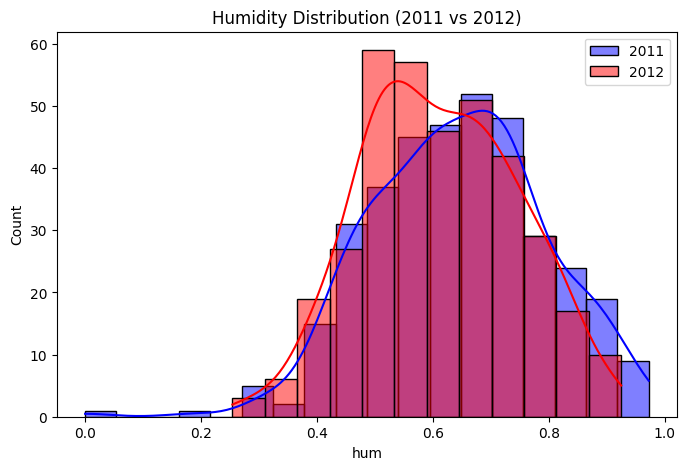

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df_2011["hum"], color="blue", label="2011", kde=True)
sns.histplot(df_2012["hum"], color="red", label="2012", kde=True)

plt.legend()
plt.title("Humidity Distribution (2011 vs 2012)")
plt.show()

### 3.4.3 Evidently Drift Report 
- Evidently shows that feature 'hum' has drift detected with a drift score of 0.009282.

In [49]:
# Use FEATURES ONLY for drift (do NOT include target 'cnt')
reference_data = X_ref.copy()
current_data = X_curr.copy()

# Build drift report
drift_report = Report(metrics=[DataDriftPreset()])
drift_report.run(reference_data=reference_data, current_data=current_data)

# Save as HTML artifact
drift_html_path = "evidently_data_drift_report.html"
drift_report.save_html(drift_html_path)

# Save as JSON artifact (machine-readable)
drift_json_path = "evidently_data_drift_report.json"
report_json = drift_report.as_dict()
with open(drift_json_path, "w", encoding="utf-8") as f:
    json.dump(report_json, f, indent=2)

(drift_html_path, drift_json_path)

('evidently_data_drift_report.html', 'evidently_data_drift_report.json')

## 3.5 Impact of Drift on Model Performance

In [50]:
# --- Performance on 2011 (reference) ---
y_pred_2011 = ridge_model.predict(X_ref)

rmse_2011 = np.sqrt(mean_squared_error(y_ref, y_pred_2011))
mae_2011 = mean_absolute_error(y_ref, y_pred_2011)

# --- Performance on 2012 (current/drifted) ---
y_pred_2012 = ridge_model.predict(X_curr)

rmse_2012 = np.sqrt(mean_squared_error(y_curr, y_pred_2012))
mae_2012 = mean_absolute_error(y_curr, y_pred_2012)

print("2011 RMSE:", rmse_2011)
print("2012 RMSE:", rmse_2012)
print("2011 MAE :", mae_2011)
print("2012 MAE :", mae_2012)

2011 RMSE: 557.4541515090796
2012 RMSE: 2342.0164706175656
2011 MAE : 412.27191476266535
2012 MAE : 2160.5822725636876


In [51]:
DRIFT_RUN_ID = None

with mlflow.start_run(run_name="Task2_Data_Drift_Check") as drift_run:
    DRIFT_RUN_ID = drift_run.info.run_id

    # Identify purpose
    mlflow.set_tag("role", "drift_monitoring")
    mlflow.set_tag("model_monitored", "RidgeRegression")

    # performance drift metrics
    mlflow.log_metric("rmse_2011", rmse_2011)
    mlflow.log_metric("rmse_2012", rmse_2012)
    mlflow.log_metric("mae_2011", mae_2011)
    mlflow.log_metric("mae_2012", mae_2012)
    mlflow.log_metric("rmse_change", rmse_2012 - rmse_2011)

    # Dataset info
    mlflow.log_param("reference_dataset", "day_2011.csv")
    mlflow.log_param("current_dataset", "day_2012.csv")
    mlflow.log_param("reference_rows", len(reference))
    mlflow.log_param("current_rows", len(current))
    mlflow.log_param("num_features", X_ref.shape[1])

    # Log Evidently reports
    mlflow.log_artifact(drift_html_path)
    mlflow.log_artifact(drift_json_path)

print("Drift Run ID:", DRIFT_RUN_ID)

🏃 View run Task2_Data_Drift_Check at: http://localhost:5000/#/experiments/6/runs/4aa4ee637a6c4be897cc4c8dde1b1b32
🧪 View experiment at: http://localhost:5000/#/experiments/6
Drift Run ID: 4aa4ee637a6c4be897cc4c8dde1b1b32


## 3.6 Recommended Operational Action
- Retrains model using combined dataset from year 2011 and 2012.
- Compare RMSE of year 2012 using old model and new model.
- Determine if model performance has improved or not.

In [52]:
# Combine
df_combined = pd.concat([df_2011, df_2012], ignore_index=True)

# performs the train-test-split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    df_combined.drop(columns="cnt"),
    df_combined["cnt"],
    test_size=0.2,
    random_state=142
)

In [53]:
# retrain ridge model using both 2011 and 2012 datasets
ridge_retrained = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=0.5))
])

ridge_retrained.fit(X_train_new, y_train_new)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
# OLD model performance on 2012
old_pred_2012 = ridge_model.predict(X_curr)
old_rmse_2012 = np.sqrt(mean_squared_error(y_curr, old_pred_2012))

# RETRAINED model performance on 2012
new_pred_2012 = ridge_retrained.predict(X_curr)
new_rmse_2012 = np.sqrt(mean_squared_error(y_curr, new_pred_2012))

print("Old model RMSE on 2012:", old_rmse_2012)
print("Retrained model RMSE on 2012:", new_rmse_2012)

Old model RMSE on 2012: 2342.0164706175656
Retrained model RMSE on 2012: 1287.195276815718
